In [1]:
import cv2
from pathlib import Path
import torch
from facenet_pytorch import MTCNN
from tqdm import tqdm
import matplotlib.pyplot as plt


In [2]:
device= "cuda" if torch.cuda.is_available() else "cpu"
print("using device", device)
mtcnn = MTCNN(image_size=224, margin=20, device=device, thresholds=[0.9,0.9,0.9])

using device cuda


/home/yogeshwar/Desktop/deepfake-video-detector/venv/lib/python3.11/site-packages/facenet_pytorch/models/mtcnn.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dic

In [3]:
from PIL import Image
raw_dir=Path("../data/raw")
real_videos = list((raw_dir / "original").glob("*.mp4"))
fake_videos=list((raw_dir / "Deepfakes").glob("*.mp4"))

In [4]:
cap = cv2.VideoCapture(str(real_videos[0]))
ret, frame = cap.read()
cap.release()

frame_rgb  = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
pil_frame  = Image.fromarray(frame_rgb)

face = mtcnn(pil_frame)

In [5]:
print(type(face))
print(face.shape if face is not None else "No face detected")

<class 'torch.Tensor'>
torch.Size([3, 224, 224])


In [6]:
face_np = face.permute(1,2,0).numpy()
face_np = (face_np - face_np.min()) / (face_np.max() - face_np.min())


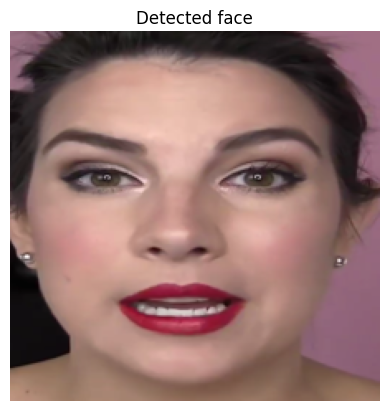

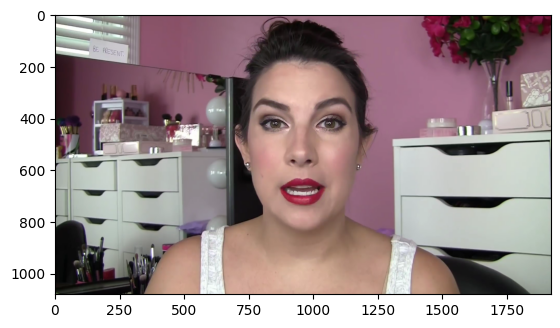

In [7]:
plt.imshow(face_np)
plt.axis("off")
plt.title("Detected face")
plt.show()

plt.imshow(frame_rgb)

In [8]:
boxes, probs = mtcnn.detect(pil_frame)
print("boxes", boxes)
print("probs", probs)

boxes [[743.8547973632812 162.549072265625 1205.667724609375 836.8826293945312]]
probs [0.996775209903717]


In [9]:
filename=Path(real_videos[0].name)
print(filename)

965.mp4


In [10]:
def get_split(video_num):
    if video_num < 720:
        return "train"
    elif video_num < 860: 
        return "val"
    else:
        return "test"

In [11]:
from tqdm.notebook import tqdm

def save_faces(videos, label):
    for video in tqdm(videos, desc=f"Processing {label}"):
        cap = None
        try:
            if label == "real":
                video_num = int(Path(video.name).stem)
            else:
                video_num=int(Path(video.name).stem.split("_")[0])
                
            split=get_split(video_num)
            cap = cv2.VideoCapture(str(video))
        
            saved_count=0
            while True:
                ret, frame = cap.read()
                if not ret or saved_count >= 30:
                    break
                frame_rgb=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
                pil_frame=Image.fromarray(frame_rgb)
                face=mtcnn(pil_frame)
                if face is not None:
                    face_np=((face.permute(1,2,0).numpy()+1)/2*255).astype("uint8")
                    face_bgr = cv2.cvtColor(face_np, cv2.COLOR_RGB2BGR)
                    
                    name=f"{Path(video.name).stem}_{saved_count}.jpg"
                    cv2.imwrite(f"../data/processed/{split}/{label}/{name}", face_bgr)
                    saved_count+=1
                for _ in range(9):
                    cap.grab()
        except Exception as e:
            print(f"Error processing {video.name}: {e}")
        finally:
            if cap is not None:
                cap.release()
            
            
            

In [12]:
save_faces(fake_videos, "fake")

Processing fake:   0%|          | 0/1000 [00:00<?, ?it/s]

In [13]:
save_faces(real_videos,"real")

Processing real:   0%|          | 0/1000 [00:00<?, ?it/s]

In [14]:
print(next(mtcnn.parameters()).device)

cuda:0


In [ ]:
import os

real_samples= list(Path("../data/processed/").rglob("real/*.jpg"))[:10]
fake_samples=list(Path("../data/processed/").rglob("fake/*.jpg"))[:10]

fig,axes = plt.subplots(2,4,figsize=(12,6))
for i,ax in enumerate(axes[0]):
    img = cv2.imread(str(real_samples[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Real")
    ax.axis("off")

plt.show()


In [15]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Laptop GPU
